In [1]:
import pandas as pd
import seaborn as sns
import math
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

In [44]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

y_train = y_train.squeeze()
y_test = y_test.squeeze()

# Czysty model

In [45]:
# uzupełnianie braków np. średnią
imputer = SimpleImputer(strategy='mean')

# definicja selektora cech
feature_selector = SelectFromModel(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=42)
)

# definicja docelowego klasyfikatora
classifier = LogisticRegression(penalty='l2', C=1.0, class_weight='balanced', random_state=42, max_iter=1000)

model_pipeline = Pipeline([
    ('imputation', imputer),
    ('feature_selection', feature_selector),
    ('classification', classifier)
])

# Trening modelu
model_pipeline.fit(X_train, y_train)

# Wyświetlenie, ile cech zostało wybranych
selected_features_mask = model_pipeline.named_steps['feature_selection'].get_support()
selected_feature_names = X_train.columns[selected_features_mask]
print(f"Wybrano {len(selected_feature_names)} z {X_train.shape[1]} cech.")
print(f"Wybrane cechy: {list(selected_feature_names)}\n")

y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

Wybrano 14 z 16 cech.
Wybrane cechy: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'gender_Male', 'ever_married_Yes', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']



# Macierz pomyłek

------------------------------ Macierz Pomyłek ------------------------------


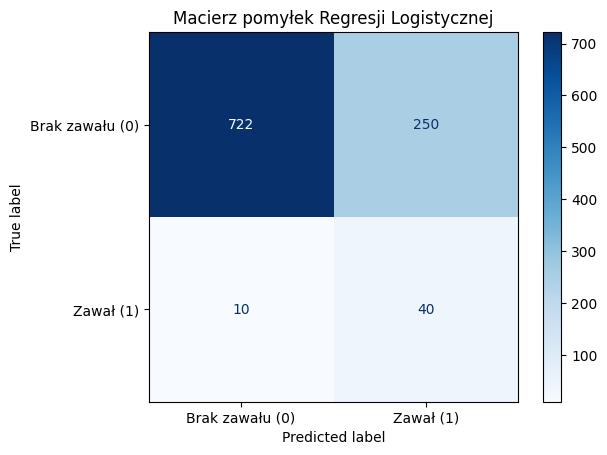

In [46]:
print(30*"-", "Macierz Pomyłek", 30*"-")
cm = confusion_matrix(y_test, y_pred)
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Brak zawału (0)", "Zawał (1)"])
disp_cm.plot(cmap='Blues', values_format='d')
plt.title("Macierz pomyłek Regresji Logistycznej")
plt.show()

In [47]:
import numpy as np
from sklearn.metrics import (
    make_scorer,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    fbeta_score,
    classification_report
)

def business_profit_score(y_true, y_pred):
    """
    Oblicza zysk biznesowy dla zadania.
    +1 za uratowane życie (True Positive - TP).
    -0.25 za utraconego pacjenta (False Positive - FP),
    ponieważ co czwarty fałszywy alarm pacjent odinstalowujący aplikację.
    """
    _, fp, _, tp = confusion_matrix(y_true, y_pred).ravel()

    return tp - (0.25 * fp)

# Tworzymy obiekt scorer gotowy do użycia
custom_business_scorer = make_scorer(business_profit_score, greater_is_better=True)

# Tworzymy osobną metrykę F2 do śledzenia (Czułość jest dla nas 2x ważniejsza)
f2_scorer = make_scorer(fbeta_score, beta=2)

# Słownik wszystkich metryk do wykorzystania w GridSearchCV (parametr: scoring=scoring_dict)
scoring_dict = {
    'Business_Score': custom_business_scorer,
    'F2_Score': f2_scorer,
    'ROC_AUC': 'roc_auc',
    'PR_AUC': 'average_precision'
}


def evaluate_heart_model(model, X_test, y_test):
    """
    Wypisuje pełny raport skuteczności modelu przetestowanego na zbiorze testowym.
    """
    y_pred = model.predict(X_test)

    # Pobieramy prawdopodobieństwa (potrzebne do ROC i PR AUC)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # Fallback np. dla dec_function
        y_proba = model.decision_function(X_test)

    print("--- WYNIKI MODELU: SYSTEM OSTRZEGANIA PRZED ZAWAŁEM ---")
    print(f"Zysk Biznesowy (TP - 0.25*FP): {business_profit_score(y_test, y_pred):.2f}")
    print(f"F2-Score (Nacisk na Czułość):  {fbeta_score(y_test, y_pred, beta=2):.4f}")
    print(f"ROC AUC:                       {roc_auc_score(y_test, y_proba):.4f}")
    print(f"PR AUC (Average Precision):    {average_precision_score(y_test, y_proba):.4f}")
    print("\n--- SZCZEGÓŁOWY RAPORT KLASYFIKACJI ---")
    print(classification_report(y_test, y_pred))

# Wyniki modelu przed eksperymentami

In [31]:
evaluate_heart_model(model_pipeline,X_test, y_test)

--- WYNIKI MODELU: SYSTEM OSTRZEGANIA PRZED ZAWAŁEM ---
Zysk Biznesowy (TP - 0.25*FP): -22.25
F2-Score (Nacisk na Czułość):  0.4090
ROC AUC:                       0.8438
PR AUC (Average Precision):    0.2672

--- SZCZEGÓŁOWY RAPORT KLASYFIKACJI ---
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



# Wpływ hiperparametrów

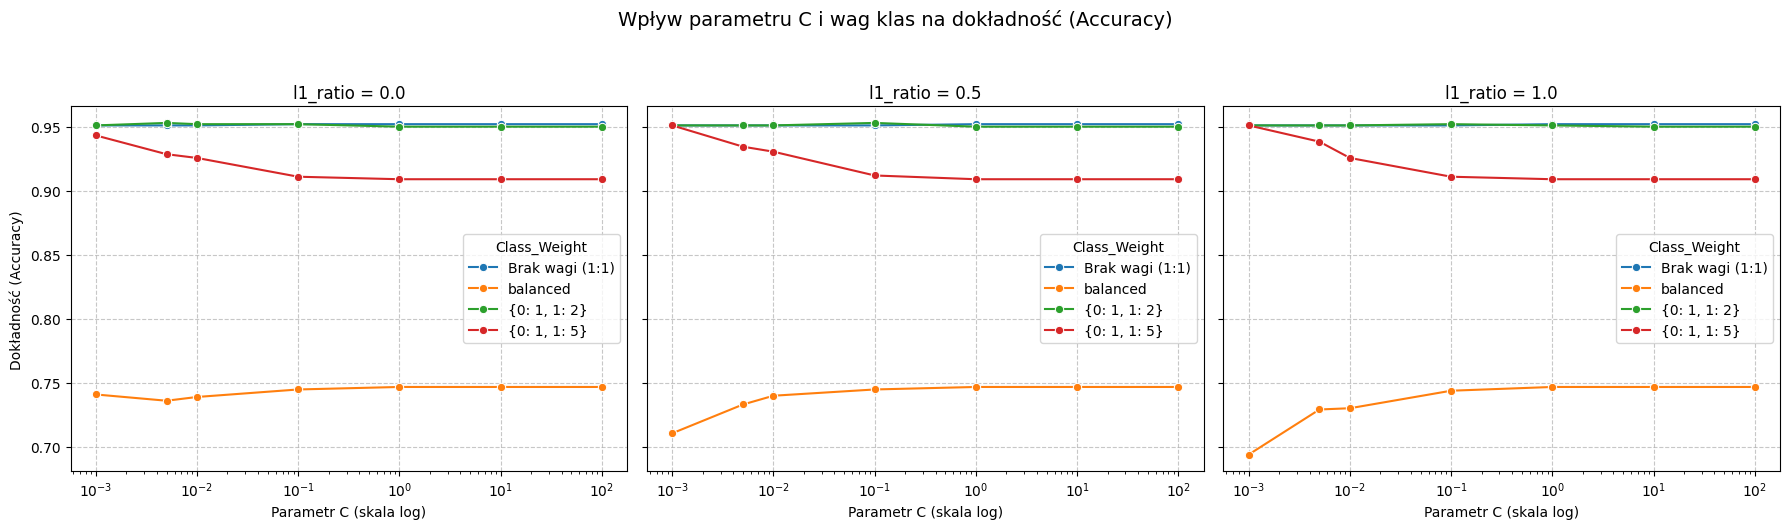

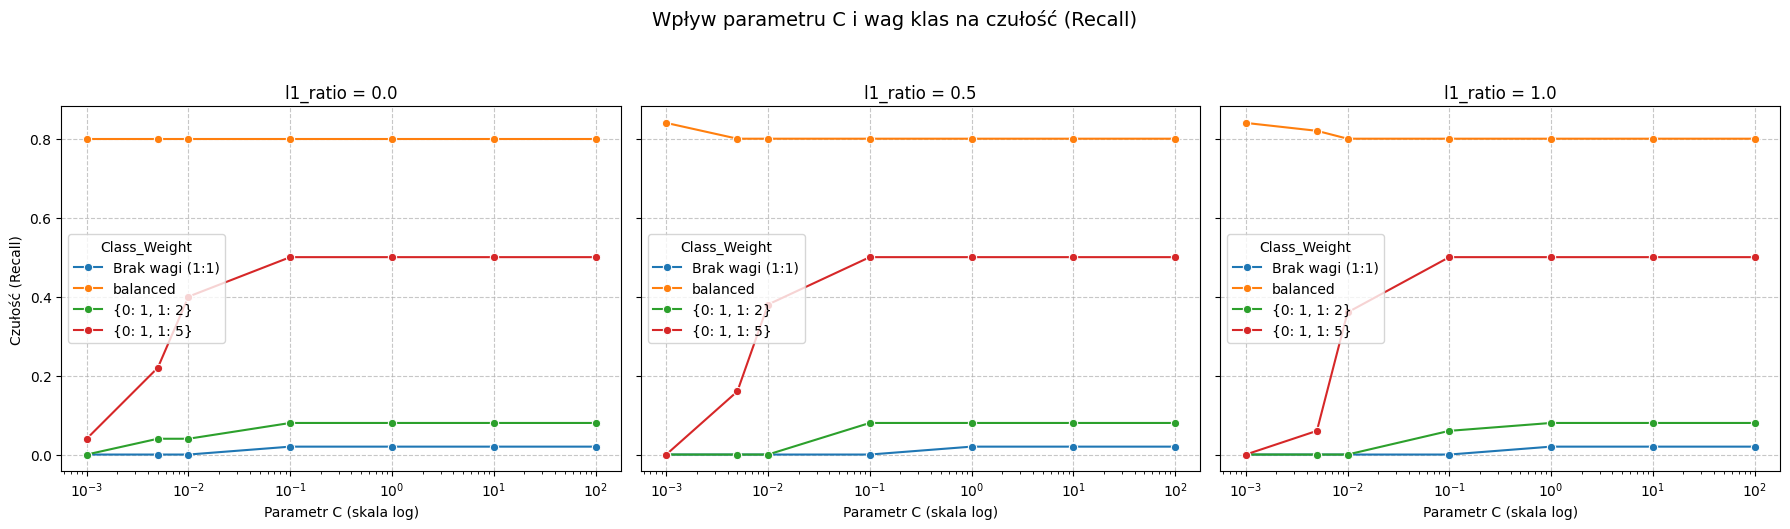

Tabela 1 - Dokładność (Accuracy):


l1_ratio                    0.0     0.5     1.0
C       Class_Weight                           
0.001   Brak wagi (1:1)  0.9511  0.9511  0.9511
        balanced         0.7407  0.7104  0.6937
        {0: 1, 1: 2}     0.9511  0.9511  0.9511
        {0: 1, 1: 5}     0.9432  0.9511  0.9511
0.005   Brak wagi (1:1)  0.9511  0.9511  0.9511
        balanced         0.7358  0.7329  0.7290
        {0: 1, 1: 2}     0.9530  0.9511  0.9511
        {0: 1, 1: 5}     0.9286  0.9344  0.9384
0.010   Brak wagi (1:1)  0.9511  0.9511  0.9511
        balanced         0.7387  0.7397  0.7299
        {0: 1, 1: 2}     0.9521  0.9511  0.9511
        {0: 1, 1: 5}     0.9256  0.9305  0.9256
0.100   Brak wagi (1:1)  0.9521  0.9511  0.9511
        balanced         0.7446  0.7446  0.7436
        {0: 1, 1: 2}     0.9521  0.9530  0.9521
        {0: 1, 1: 5}     0.9110  0.9119  0.9110
1.000   Brak wagi (1:1)  0.9521  0.9521  0.9521
        balanced         0.7466  0.7466  0.7466
        {0: 1, 1: 2}     0.9501  0.9501  0.9511
        {0: 1, 1: 5}     0.9090  0.9090  0.9090
10.000  Brak wagi (1:1)  0.9521  0.9521  0.9521
        balanced         0.7466  0.7466  0.7466
        {0: 1, 1: 2}     0.9501  0.9501  0.9501
        {0: 1, 1: 5}     0.9090  0.9090  0.9090
100.000 Brak wagi (1:1)  0.9521  0.9521  0.9521
        balanced         0.7466  0.7466  0.7466
        {0: 1, 1: 2}     0.9501  0.9501  0.9501
        {0: 1, 1: 5}     0.9090  0.9090  0.9090


Tabela 2 - Czułość (Recall):


l1_ratio                  0.0   0.5   1.0
C       Class_Weight                     
0.001   Brak wagi (1:1)  0.00  0.00  0.00
        balanced         0.80  0.84  0.84
        {0: 1, 1: 2}     0.00  0.00  0.00
        {0: 1, 1: 5}     0.04  0.00  0.00
0.005   Brak wagi (1:1)  0.00  0.00  0.00
        balanced         0.80  0.80  0.82
        {0: 1, 1: 2}     0.04  0.00  0.00
        {0: 1, 1: 5}     0.22  0.16  0.06
0.010   Brak wagi (1:1)  0.00  0.00  0.00
        balanced         0.80  0.80  0.80
        {0: 1, 1: 2}     0.04  0.00  0.00
        {0: 1, 1: 5}     0.40  0.38  0.36
0.100   Brak wagi (1:1)  0.02  0.00  0.00
        balanced         0.80  0.80  0.80
        {0: 1, 1: 2}     0.08  0.08  0.06
        {0: 1, 1: 5}     0.50  0.50  0.50
1.000   Brak wagi (1:1)  0.02  0.02  0.02
        balanced         0.80  0.80  0.80
        {0: 1, 1: 2}     0.08  0.08  0.08
        {0: 1, 1: 5}     0.50  0.50  0.50
10.000  Brak wagi (1:1)  0.02  0.02  0.02
        balanced         0.80  0.80  0.80
        {0: 1, 1: 2}     0.08  0.08  0.08
        {0: 1, 1: 5}     0.50  0.50  0.50
100.000 Brak wagi (1:1)  0.02  0.02  0.02
        balanced         0.80  0.80  0.80
        {0: 1, 1: 2}     0.08  0.08  0.08
        {0: 1, 1: 5}     0.50  0.50  0.50

In [37]:
from sklearn.metrics import recall_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c_values = [0.001, 0.005, 0.01, 0.1, 1.0, 10.0, 100.0]
l1_values = [0.0, 0.5, 1.0]

class_weights = [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 5}]

results = []

for c in c_values:
    for l1 in l1_values:
        for cw in class_weights:

            cw_name = str(cw) if isinstance(cw, dict) else str(cw)
            if cw_name == 'None': cw_name = 'Brak wagi (1:1)'

            classifier = LogisticRegression(
                penalty='elasticnet',
                solver='saga',
                C=c,
                l1_ratio=l1,
                max_iter=5000,
                random_state=42,
                class_weight=cw
            )

            model_pipeline = Pipeline([
                ('imputation', imputer),
                ('scaling', StandardScaler()),
                ('feature_selection', feature_selector),
                ('classification', classifier)
            ])

            model_pipeline.fit(X_train, y_train)
            acc = model_pipeline.score(X_test, y_test)
            y_pred = model_pipeline.predict(X_test)
            rec = recall_score(y_test, y_pred)

            results.append({'C': c, 'l1_ratio': l1, 'Class_Weight': cw_name, 'Accuracy': acc, 'Recall': rec})

df_results = pd.DataFrame(results)

fig_acc, axes_acc = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig_acc.suptitle('Wpływ parametru C i wag klas na dokładność (Accuracy)', fontsize=14, y=1.05)

for i, l1 in enumerate(l1_values):
    subset = df_results[df_results['l1_ratio'] == l1]
    sns.lineplot(data=subset, x='C', y='Accuracy', hue='Class_Weight', marker='o', ax=axes_acc[i])
    axes_acc[i].set_xscale('log')
    axes_acc[i].set_title(f'l1_ratio = {l1}')
    axes_acc[i].set_xlabel('Parametr C (skala log)')
    if i == 0:
        axes_acc[i].set_ylabel('Dokładność (Accuracy)')
    axes_acc[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

fig_rec, axes_rec = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig_rec.suptitle('Wpływ parametru C i wag klas na czułość (Recall)', fontsize=14, y=1.05)

for i, l1 in enumerate(l1_values):
    subset = df_results[df_results['l1_ratio'] == l1]
    sns.lineplot(data=subset, x='C', y='Recall', hue='Class_Weight', marker='o', ax=axes_rec[i])
    axes_rec[i].set_xscale('log')
    axes_rec[i].set_title(f'l1_ratio = {l1}')
    axes_rec[i].set_xlabel('Parametr C (skala log)')
    if i == 0:
        axes_rec[i].set_ylabel('Czułość (Recall)')
    axes_rec[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("Tabela 1 - Dokładność (Accuracy):")
df_pivot_acc = df_results.pivot_table(index=['C', 'Class_Weight'], columns='l1_ratio', values='Accuracy')
display(df_pivot_acc.round(4))

print("\nTabela 2 - Czułość (Recall):")
df_pivot_rec = df_results.pivot_table(index=['C', 'Class_Weight'], columns='l1_ratio', values='Recall')
display(df_pivot_rec.round(4))

# Ostateczne wyniki

In [32]:
from sklearn.model_selection import GridSearchCV

# 1. Definicja siatki hiperparametrów dla kroku klasyfikacji w potoku
param_grid = {
    'classification__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'classification__l1_ratio': [0.0, 0.5, 1.0],
    'classification__class_weight': ['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}]
}

# 2. Definicja bazowego klasyfikatora i potoku
base_classifier = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=5000,
    random_state=42
)

base_pipeline = Pipeline([
    ('imputation', imputer),
    ('scaling', StandardScaler()),
    ('feature_selection', feature_selector),
    ('classification', base_classifier)
])

# 3. Konfiguracja GridSearchCV - OPTYMALIZACJA BIZNESOWA
grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring=scoring_dict,
    refit='Business_Score',
    cv=5,
    n_jobs=-1
)

# 4. Trening i przeszukiwanie siatki
print("Rozpoczynam optymalizację pod kątem zysku biznesowego (Grid Search)...")
grid_search.fit(X_train, y_train)

# 5. Wyciągnięcie gotowego, wygranego potoku
best_pipeline = grid_search.best_estimator_

print("\nNajlepsze znalezione parametry dla maksymalizacji zysku:")
for param_name, param_value in grid_search.best_params_.items():
    print(f" - {param_name}: {param_value}")

print(f"\nNajlepszy średni Zysk Biznesowy: {grid_search.best_score_:.2f}")
print("-" * 50)

# 6. Ocena ostateczna na zbiorze testowym za pomocą Twojej metody
evaluate_heart_model(best_pipeline, X_test, y_test)

Rozpoczynam optymalizację pod kątem zysku biznesowego (Grid Search)...

Najlepsze znalezione parametry dla maksymalizacji zysku:
 - classification__C: 0.01
 - classification__class_weight: {0: 1, 1: 5}
 - classification__l1_ratio: 0.5

Najlepszy średni Zysk Biznesowy (z walidacji krzyżowej): 0.25
--------------------------------------------------
--- WYNIKI MODELU: SYSTEM OSTRZEGANIA PRZED ZAWAŁEM ---
Zysk Biznesowy (TP - 0.25*FP): 9.00
F2-Score (Nacisk na Czułość):  0.3668
ROC AUC:                       0.8401
PR AUC (Average Precision):    0.2573

--- SZCZEGÓŁOWY RAPORT KLASYFIKACJI ---
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       972
           1       0.32      0.38      0.35        50

    accuracy                           0.93      1022
   macro avg       0.64      0.67      0.66      1022
weighted avg       0.94      0.93      0.93      1022



# Walidacja krzyżowa

Tabela - Wyniki Walidacji Krzyżowej (Precyzja):
Liczba podziałów      Rodzaj_CV  Średnia Precyzja  Zmienność (Odchylenie Std)
         10-fold Stratyfikowane            0.2327                      0.1780
         10-fold  Zwykłe K-Fold            0.2187                      0.0979
          2-fold Stratyfikowane            0.2469                      0.0114
          2-fold  Zwykłe K-Fold            0.1555                      0.0179
          5-fold Stratyfikowane            0.2139                      0.0609
          5-fold  Zwykłe K-Fold            0.2088                      0.0786


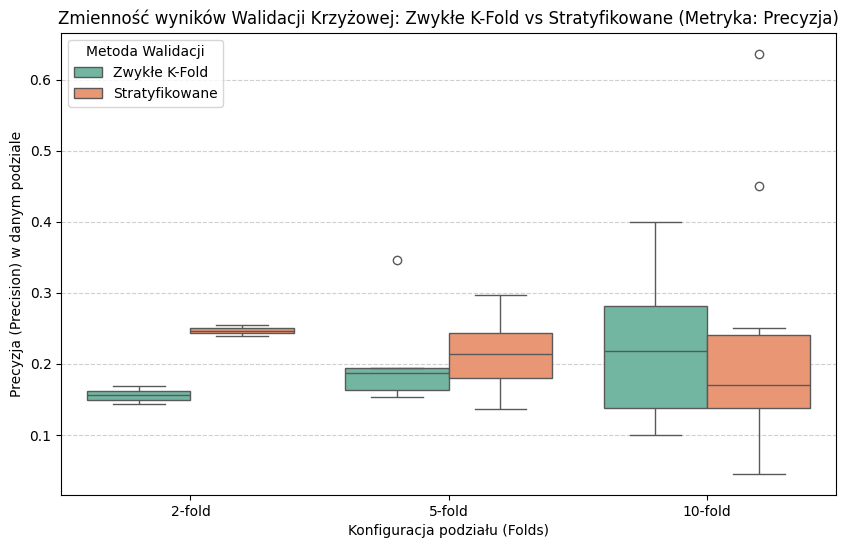

In [35]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, precision_score

precision_scorer = make_scorer(precision_score, zero_division=0.0)

folds_list = [2, 5, 10]
cv_results = []

for k in folds_list:
    # 1. Zwykłe K-Fold
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores_kf = cross_val_score(best_pipeline, X_train, y_train, cv=kf, scoring=precision_scorer)

    for score in scores_kf:
        cv_results.append({'Liczba podziałów': f'{k}-fold', 'Rodzaj_CV': 'Zwykłe K-Fold', 'Precyzja': score})

    # 2. Stratyfikowane K-Fold
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores_skf = cross_val_score(best_pipeline, X_train, y_train, cv=skf, scoring='precision')

    for score in scores_skf:
         cv_results.append({'Liczba podziałów': f'{k}-fold', 'Rodzaj_CV': 'Stratyfikowane', 'Precyzja': score})

df_cv = pd.DataFrame(cv_results)

summary_table = df_cv.groupby(['Liczba podziałów', 'Rodzaj_CV'])['Precyzja'].agg(['mean', 'std']).reset_index()
summary_table.rename(columns={'mean': 'Średnia Precyzja', 'std': 'Zmienność (Odchylenie Std)'}, inplace=True)
print("Tabela - Wyniki Walidacji Krzyżowej (Precyzja):")
print(summary_table.round(4).to_string(index=False))

# Generowanie wykresu
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cv, x='Liczba podziałów', y='Precyzja', hue='Rodzaj_CV', palette='Set2')

# Zmiana tytułu i etykiet osi
plt.title('Zmienność wyników Walidacji Krzyżowej: Zwykłe K-Fold vs Stratyfikowane (Metryka: Precyzja)')
plt.ylabel('Precyzja (Precision) w danym podziale')
plt.xlabel('Konfiguracja podziału (Folds)')
plt.legend(title='Metoda Walidacji')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()